In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [35]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

'notebook'

In [36]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        # 'LexicalNoDelay',
        # 'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='LBA',
            suffix='zscore',
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.head()

100%|██████████| 136/136 [00:12<00:00, 10.64it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.029893,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.106969,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.005561,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.047000,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.148092,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [37]:
subset = HGAs[
    (HGAs.modality == 'sound')
    & (HGAs.description == 'Repeat')
].copy()

subset['significance'] = subset.groupby(['task', 'channel'])['mask'].transform('any')
subset.head()

,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z,significance
0,-1.0,D0019_ROG1-2,-0.029893,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237,False
1,-1.0,D0019_ROG2-3,-0.106969,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434,False
2,-1.0,D0019_ROG4-5,-0.005561,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276,False
3,-1.0,D0019_ROG6-7,-0.047000,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992,False
4,-1.0,D0019_ROG7-8,-0.148092,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703,False


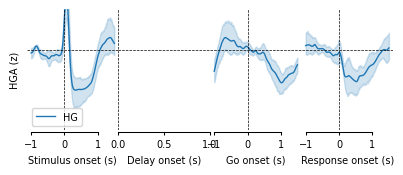

In [42]:
labels = [
    'ctx_rh_G_and_S_cingul-Mid-Ant',  
    'ctx_lh_G_and_S_cingul-Mid-Ant',  
    'ctx_rh_G_insular_short',         
    'ctx_lh_G_insular_short',         
]

rois = ['HG']
subset_ = subset[
    # (subset.label.isin(labels))
    (subset.roi.isin(rois))
    & (subset.significance == True)
]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['stimulus', 'delay', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    line = sns.lineplot(
        data=subset_[(subset_.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    ax.set_ylim(-1, 0.5)


for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

# plt.suptitle(rois[0] + ' in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/fig4/fig4_{rois[0]}_condition_difference.svg', dpi=300, bbox_inches='tight')

plt.show()

In [39]:
cords = subset_[
    (subset_.phase == 'response')
    & (subset_.description=='Repeat')
    & (subset_.time>-0.5)
    & (subset_.time<0.5)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

cords.head()

,channel,value,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0025_R2SF5-6,-0.782636,8.357315,9.206914,40.318383,CG,ctx_rh_G_and_S_cingul-Mid-Ant,response,R,D0025,Repeat,PhonemeSequence
1,D0025_R2SF6-7,-0.851591,9.242655,10.894521,43.615680,CG,ctx_rh_G_and_S_cingul-Mid-Ant,response,R,D0025,Repeat,PhonemeSequence
2,D0025_R2SF7-8,-0.722962,10.127947,12.582173,46.912926,CG,ctx_rh_G_and_S_cingul-Mid-Ant,response,R,D0025,Repeat,PhonemeSequence
3,D0028_LAI3-4,-0.273193,-34.543239,15.001830,0.344973,Insula,ctx_lh_G_insular_short,response,L,D0028,Repeat,PhonemeSequence
4,D0028_LPMF1-2,-0.175670,-6.892821,3.293320,33.866060,CG,ctx_lh_G_and_S_cingul-Mid-Ant,response,L,D0028,Repeat,PhonemeSequence


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-23 17:33:56.845 (1475.090s) [    7F1209D47440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x87cece0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-23 17:33:56.984 (1475.229s) [    7F1209D47440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x87cece0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: eg

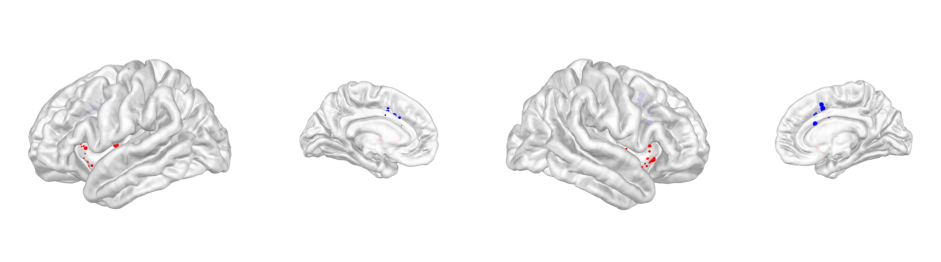

In [40]:
# Pial version - listen_hga
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 创建Brain对象 - pial surface
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.9, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.9, size=(600*cm, 600*cm)
)

# 从 listen_hga 获取数据
cord = cords[['x', 'y', 'z']].values
hga_values = np.abs(cords['value'].values)
roi_values = cords['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化
cmap = blues
vmin, vmax = 0, np.percentile(hga_values, 96)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数
size_min, size_max = 5, 40

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

# 加载 pial 表面数据
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

def add_electrodes_with_size(brain, coords, hga_vals, roi_vals, cmap, norm, size_min, size_max):
    for i in range(len(coords)):
        pt = coords[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]

        if str(roi).lower() == 'insula':
            color = (1.0, 0.0, 0.0)
        elif str(roi).lower() == 'cg':
            color = (0.0, 0.0, 1.0)
        else:
            color = cmap(norm(hga))[:3]

        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )

# 处理左半球电极 - 投影到 pial 表面
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_on_pial = lh_coords_pial[lh_indices]
    
    add_electrodes_with_size(lh_brain, lh_cord_on_pial, lh_hga, lh_roi, cmap, norm, size_min, size_max)

# 处理右半球电极 - 投影到 pial 表面
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_on_pial = rh_coords_pial[rh_indices]
    
    add_electrodes_with_size(rh_brain, rh_cord_on_pial, rh_hga, rh_roi, cmap, norm, size_min, size_max)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

# 绘图
fig, axes = plt.subplots(1, 4, figsize=(32*cm, 8*cm), gridspec_kw={'width_ratios': [2, 1, 2, 1]})

plt.subplots_adjust(wspace=-0.1)

lh_brain.show_view(view="lateral", distance=400)
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

lh_brain.show_view(view="medial", distance=400)
axes[1].imshow(lh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

rh_brain.show_view(view="lateral", distance=400)
axes[2].imshow(rh_brain.screenshot(mode="rgb"))
axes[2].axis("off")

rh_brain.show_view(view="medial", distance=400)
axes[3].imshow(rh_brain.screenshot(mode="rgb"))
axes[3].axis("off")

lh_brain.close()
rh_brain.close()

# plt.savefig('../figs/papers/fig1/fig1_HGA_perceptiononly_perception.svg', dpi=300, bbox_inches='tight')

plt.show()

# Unsupervised clustering

In [17]:
# remove the not so useful regions
subset = HGAs[~HGAs.roi.isin(
    ['OPC', 'sOccG', 'OccS', 'mOccG',
    'WM','LinG','PhG','Cb','iOccGs',
    'GRect','Amyg','Hipp','LinGs',
    'Thal','Right-Pallidum','Left-Pallidum',
    'Calcarine','CollatAnt','VDC','InfLatV','LatV',
    'CC_Central','BrainStem','CollatPost','Caud']
)]

subset = subset[
    subset.phase.isin(['stimulus','go','response'])
]
subset['significant'] = subset.groupby(['task', 'channel'])['mask'].transform('any')
subset = subset[subset.modality.isin(['sound'])]
subset = subset[subset.significant==True]
subset.head()

,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z,significant
9,-1.000000,D0019_RMOS3-4,-0.055562,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_parietal_sup,SPL,R,16.024804,-56.288230,68.934555,True
18,-1.000000,D0019_RMIH3-4,-0.126608,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_cuneus,Cun,R,2.550049,-75.411613,13.094990,True
38,-0.992188,D0019_RMOS3-4,-0.057252,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_parietal_sup,SPL,R,16.024804,-56.288230,68.934555,True
47,-0.992188,D0019_RMIH3-4,-0.129409,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_cuneus,Cun,R,2.550049,-75.411613,13.094990,True
67,-0.984375,D0019_RMOS3-4,-0.060847,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_parietal_sup,SPL,R,16.024804,-56.288230,68.934555,True


In [18]:
import xarray as xr

stimulus_stage = (subset[(subset.phase=='stimulus') 
                         &(subset.time>-0.5)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

go_stage = (subset[(subset.phase=='go') 
                         &(subset.time>-0.5)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

response_stage = (subset[(subset.phase=='response') 
                         &(subset.time>-0.5)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

# concat
concat_stage = xr.concat([stimulus_stage, go_stage, response_stage], dim='time')

valid_channels = concat_stage.dropna(dim='channel', how='any').channel.values
concat_stage = concat_stage.sel(channel=valid_channels)

In [26]:
# perform the NMF
from sklearn.decomposition import NMF

# Prepare data for NMF (channels x timepoints)
data_matrix = concat_stage.values

# Handle negative values by shifting to non-negative
data_matrix = data_matrix - data_matrix.min()

# Apply NMF
n_components = 5  # You can adjust this number
nmf = NMF(n_components=n_components, random_state=42)
W = nmf.fit_transform(data_matrix)  # Channel components
H = nmf.components_  # Temporal components

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [27]:
# Get channel coordinates from valid channels only, preserving concat_stage order
valid_channels = concat_stage.channel.values
coords = (subset[subset.channel.isin(valid_channels)]
          .groupby('channel').agg({
              'x': 'first',
              'y': 'first', 
              'z': 'first',
              'roi': 'first',
              'label': 'first',
              'hemi': 'first',
              'subject': 'first'
          })
          .loc[valid_channels]  # 保证顺序一致
          .reset_index())

# Create NMF visualization DataFrame using melt and assign
W_ = (coords
    .reindex(coords.index.repeat(n_components))
    .reset_index(drop=True)
    .assign(weight=W.flatten(),
            component=[i for i in range(n_components) for _ in range(len(coords))]))

W_.head()

,channel,x,y,z,roi,label,hemi,subject,weight,component
0,D0019_RMIH3-4,2.550049,-75.411613,13.09499,Cun,ctx_rh_G_cuneus,R,D0019,0.104309,0
1,D0019_RMIH3-4,2.550049,-75.411613,13.09499,Cun,ctx_rh_G_cuneus,R,D0019,0.127172,0
2,D0019_RMIH3-4,2.550049,-75.411613,13.09499,Cun,ctx_rh_G_cuneus,R,D0019,0.166186,0
3,D0019_RMIH3-4,2.550049,-75.411613,13.09499,Cun,ctx_rh_G_cuneus,R,D0019,0.172336,0
4,D0019_RMIH3-4,2.550049,-75.411613,13.09499,Cun,ctx_rh_G_cuneus,R,D0019,0.700676,0


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-23 17:29:34.942 (1213.187s) [    7F1209D47440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2c0583e0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-23 17:29:35.043 (1213.288s) [    7F1209D47440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2c0583e0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

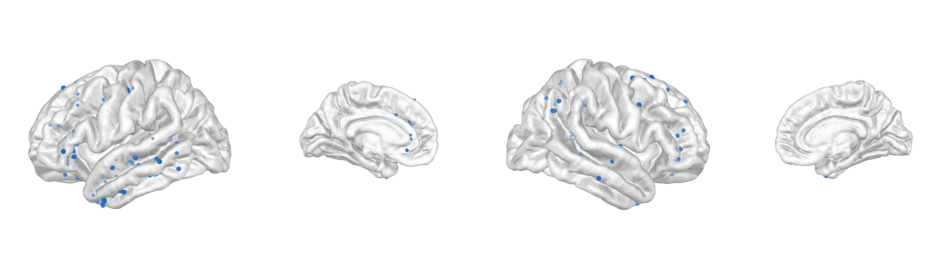

In [31]:
# Pial version - NMF weights visualization
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.9, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.9, size=(600*cm, 600*cm)
)

i=2
coords = W_[W_.component == i][['x', 'y', 'z']].values
weight_values = W_[W_.component == i]['weight'].values

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

# 设置 colormap 和归一化
cmap = blues
vmin, vmax = np.percentile(weight_values, 2), np.percentile(weight_values, 98)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数
size_min, size_max = 1, 30

def weight_to_size(weight, vmin, vmax, size_min, size_max):
    normalized = np.clip((weight - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

# 加载 pial 表面数据
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

def add_electrodes_with_size(brain, coords, weight_vals, cmap, norm, size_min, size_max):
    for i in range(len(coords)):
        pt = coords[i:i+1]
        weight = weight_vals[i]

        color = cmap(norm(weight))[:3]
        size = weight_to_size(weight, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )

# 处理左半球电极 - 投影到 pial 表面
if mask_lh.any():
    lh_coords = coords[mask_lh]
    lh_weights = weight_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_coords)
    lh_coords_on_pial = lh_coords_pial[lh_indices]
    
    add_electrodes_with_size(lh_brain, lh_coords_on_pial, lh_weights, cmap, norm, size_min, size_max)

# 处理右半球电极 - 投影到 pial 表面
if mask_rh.any():
    rh_coords = coords[mask_rh]
    rh_weights = weight_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_coords)
    rh_coords_on_pial = rh_coords_pial[rh_indices]
    
    add_electrodes_with_size(rh_brain, rh_coords_on_pial, rh_weights, cmap, norm, size_min, size_max)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, axes = plt.subplots(1, 4, figsize=(32*cm, 8*cm), gridspec_kw={'width_ratios': [2, 1, 2, 1]})

plt.subplots_adjust(wspace=-0.1)

lh_brain.show_view(view="lateral", distance=400)
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

lh_brain.show_view(view="medial", distance=400)
axes[1].imshow(lh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

rh_brain.show_view(view="lateral", distance=400)
axes[2].imshow(rh_brain.screenshot(mode="rgb"))
axes[2].axis("off")

rh_brain.show_view(view="medial", distance=400)
axes[3].imshow(rh_brain.screenshot(mode="rgb"))
axes[3].axis("off")

lh_brain.close()
rh_brain.close()

# plt.savefig('../figs/papers/fig1/fig1_HGA_perceptiononly_perception.svg', dpi=300, bbox_inches='tight')

plt.show()

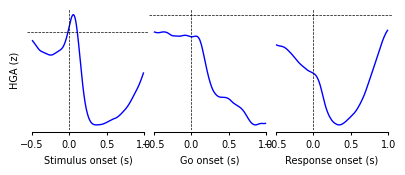

In [32]:

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

comp_idx = i

for (ax, phase) in zip(fig.axes, ['stimulus', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    xdata = (subset[(subset.phase==phase) 
                         &(subset.time>-0.5)
                         &(subset.time<1)
                         &(subset.channel.isin(valid_channels))]
        .groupby(['channel','time'])['value']
        .mean()
        .to_xarray()
    )

    weight = W[:, comp_idx]
    
    this_component = xdata * weight[:, np.newaxis]
    component_signal = this_component.sum(dim='channel')
    
    line = ax.plot(component_signal.time.values,
                   component_signal.values,
                   'b-',
                   linewidth=1)

    # ax.set_ylim(-2, 100)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Go onset (s)', fontsize=7)   
ax3.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)

# plt.suptitle(rois[0] + ' in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/fig4/fig4_{rois[0]}_condition_difference.svg', dpi=300, bbox_inches='tight')

plt.show()